<a href="https://colab.research.google.com/github/Abidau/PCVK_Ganjil_26-27/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Naufal Abid Aurizky'
NIM  = '244107020212'

N = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Naufal Abid Aurizky
NIM    : 244107020212 | N = 212
b      : 49
a      : 1.5
c      : 42
gamma  : 0.9
bit    : 4
WAKTU  : 2026-09-18 13:56:57 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 18d861582782f86a


## Setup Awal

Mount Google Drive, import library, dan siapkan fungsi bantu untuk menampilkan citra berdampingan.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from math import log10, sqrt

BASE = '/content/drive/MyDrive/PCVK/Images/' + NIM

def cv2_imshow_rgb(ax, img, title):
    """Menampilkan citra BGR (OpenCV) sebagai RGB di axis matplotlib"""
    if len(img.shape) == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def tampil_2(img1, img2, judul1, judul2, figsize=(10,5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    cv2_imshow_rgb(axs[0], img1, judul1)
    cv2_imshow_rgb(axs[1], img2, judul2)
    plt.tight_layout()
    plt.show()

print(BASE)

/content/drive/MyDrive/PCVK/Images/244107020212


## Tugas 1 — Inverse Citra

Inverse citra dihitung dengan `g(x,y) = 255 - f(x,y)` untuk setiap warna. Jadi akan membalik nilai pixel yang tadinya gelap menjadi terang, atau sebaliknya.

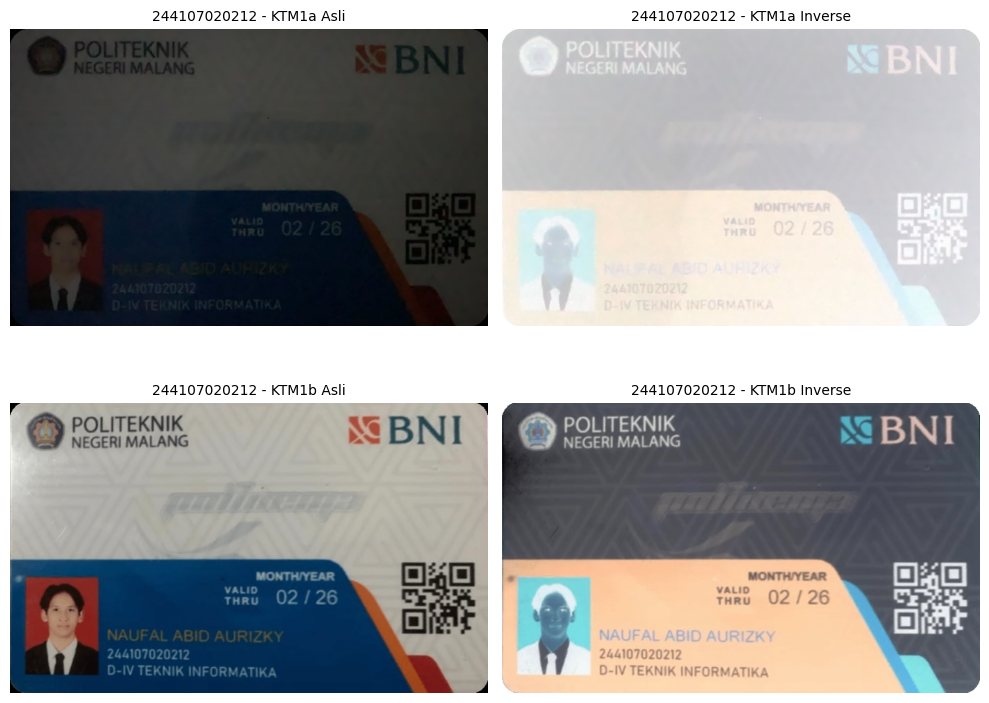

In [7]:
ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1b = cv.imread(BASE + '/KTM1b.jpg')

inv_a = 255 - ktm1a
inv_b = 255 - ktm1b

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
cv2_imshow_rgb(axs[0,0], ktm1a, NIM + ' - KTM1a Asli')
cv2_imshow_rgb(axs[0,1], inv_a, NIM + ' - KTM1a Inverse')
cv2_imshow_rgb(axs[1,0], ktm1b, NIM + ' - KTM1b Asli')
cv2_imshow_rgb(axs[1,1], inv_b, NIM + ' - KTM1b Inverse')
plt.tight_layout()
plt.show()


### Jawaban Analisis Tugas 1

- Histogram KTM1a ktm yang di ruangan gelap nilai pixel rendah, saat di inverse nilai rendah menjadi tinggi (255 - nila_rendah = nilai_tinggi), yang menjadi seluruh citra bergeser ke area terang yang akan menghasilkan terlihat pucat atau berkabut mendekati putih, tidak ada kontras.

- KTM1b dengan pencahayaan ruangan mempunyai histogram lebih merata, sehingga setelah di inverse rentang nilainya tetap lebar yang menghasilkan tetap kontras


## Tugas 2 — Transformasi Kontras

`g(x,y) = a * f(x,y) + b`, dengan `a` = nilai kontras (PARAM['a']) dan `b` = brightness (opsional, bisa 0 atau PARAM['b']).
Karena hasil operasi bisa keluar dari rentang 0–255`


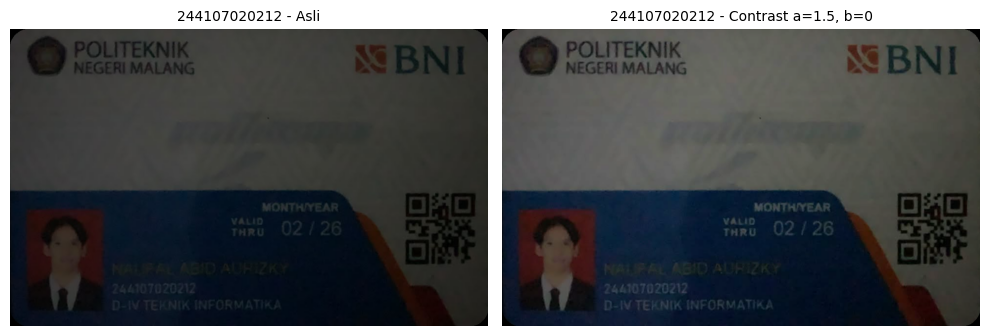

In [10]:
a = PARAM['a']
b = 0

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
contrast_image = np.clip(ktm1a.astype(np.float64) * a + b, 0, 255).astype(np.uint8)

tampil_2(ktm1a, contrast_image,
         NIM + ' - Asli',
         NIM + f' - Contrast a={a}, b={b}')



## Tugas 3 — Transformasi Logarithmic Brightness vs Linear Brightness

- Log brightness: `s = c * log(1 + r)`, dengan `c` = PARAM['c']. Cocok untuk melebarkan detail pada citra gelap tanpa membuat area terang langsung clipping ke 255.
- Linear brightness: `g(x,y) = f(x,y) + b`, dengan `b` = PARAM['b'].


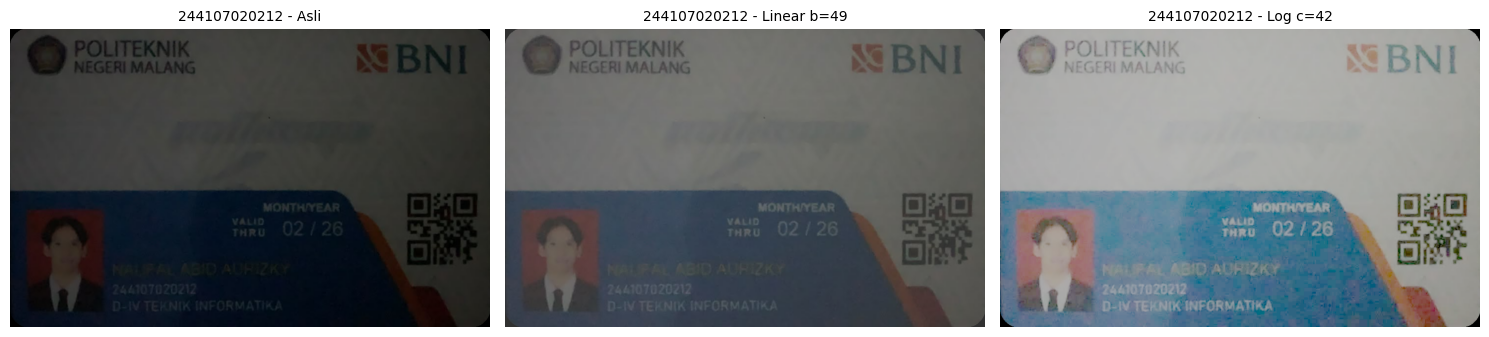

Jumlah pixel clipping (nilai 255) - Linear: 0, Log: 0


In [11]:
c_val = PARAM['c']
b_val = PARAM['b']

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
img_f = ktm1a.astype(np.float64)

# Transformasi Log
log_image = c_val * np.log1p(img_f)          # log1p = log(1+r)
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

# Transformasi Linear
linear_image = np.clip(img_f + b_val, 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cv2_imshow_rgb(axs[0], ktm1a, NIM + ' - Asli')
cv2_imshow_rgb(axs[1], linear_image, NIM + f' - Linear b={b_val}')
cv2_imshow_rgb(axs[2], log_image, NIM + f' - Log c={c_val}')
plt.tight_layout()
plt.show()

clip_linear = np.sum(linear_image == 255)
clip_log = np.sum(log_image == 255)
print(f'Jumlah pixel clipping (nilai 255) - Linear: {clip_linear}, Log: {clip_log}')


## Tugas 4 — Grayscale: Averaging, Lightness, Luminance

- Averaging: `(R+G+B)/3`
- Lightness: `(max(R,G,B) + min(R,G,B)) / 2`
- Luminance: `0.21R + 0.72G + 0.07B` (dipakai pada modul ini)
- Pembanding Luminance: `0.299R + 0.587G + 0.114B` — dipakai di `cv.cvtColor(img, cv.COLOR_BGR2GRAY)`


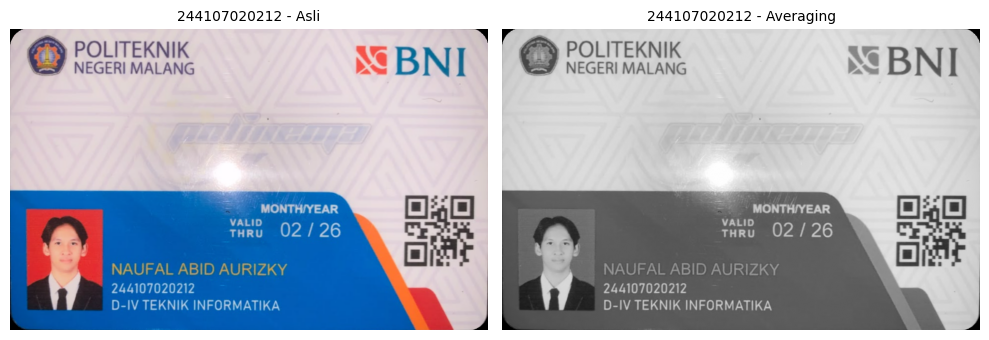

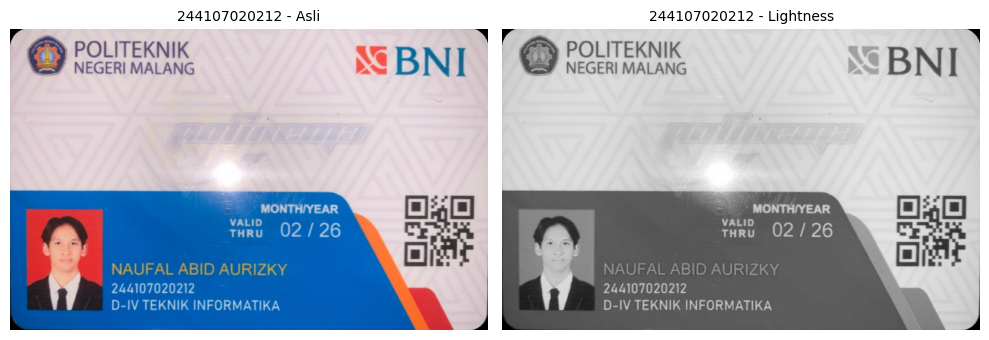

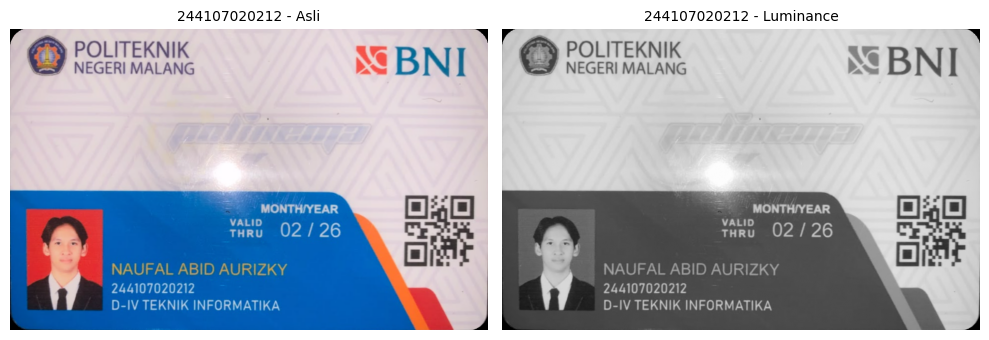

Metode                    Mean     Std Dev
Averaging               165.12       59.01
Lightness               166.38       59.19
Luminance               159.56       64.04


In [14]:
img_c = cv.imread(BASE + '/KTM1c.jpg')
b_ch, g_ch, r_ch = cv.split(img_c.astype(np.float64))

gray_avg    = (r_ch + g_ch + b_ch) / 3
gray_light  = (np.maximum(np.maximum(r_ch, g_ch), b_ch) + np.minimum(np.minimum(r_ch, g_ch), b_ch)) / 2
gray_lum = 0.299 * r_ch + 0.587 * g_ch + 0.114 * b_ch

gray_avg_u8    = np.clip(gray_avg, 0, 255).astype(np.uint8)
gray_light_u8  = np.clip(gray_light, 0, 255).astype(np.uint8)
gray_lum_u8 = np.clip(gray_lum, 0, 255).astype(np.uint8)

# a. Averaging
tampil_2(img_c, gray_avg_u8, NIM + ' - Asli', NIM + ' - Averaging')
# b. Lightness
tampil_2(img_c, gray_light_u8, NIM + ' - Asli', NIM + ' - Lightness')
# c. Luminance
tampil_2(img_c, gray_lum_u8, NIM + ' - Asli', NIM + ' - Luminance')

# Tabel rata-rata dan simpangan baku
print(f"{'Metode':<20}{'Mean':>10}{'Std Dev':>12}")
for nama, arr in [('Averaging', gray_avg_u8), ('Lightness', gray_light_u8),
                  ('Luminance ', gray_lum_u8)]:
    print(f"{nama:<20}{np.mean(arr):>10.2f}{np.std(arr):>12.2f}")


## Tugas 5 — Color Masking dengan HSV

Mempertahankan satu warna dominan pada citra, dan mengubah bagian lain menjadi grayscale. Menggunakan ruang warna HSV karena lebih mudah menentukan rentang warna dibanding RGB.

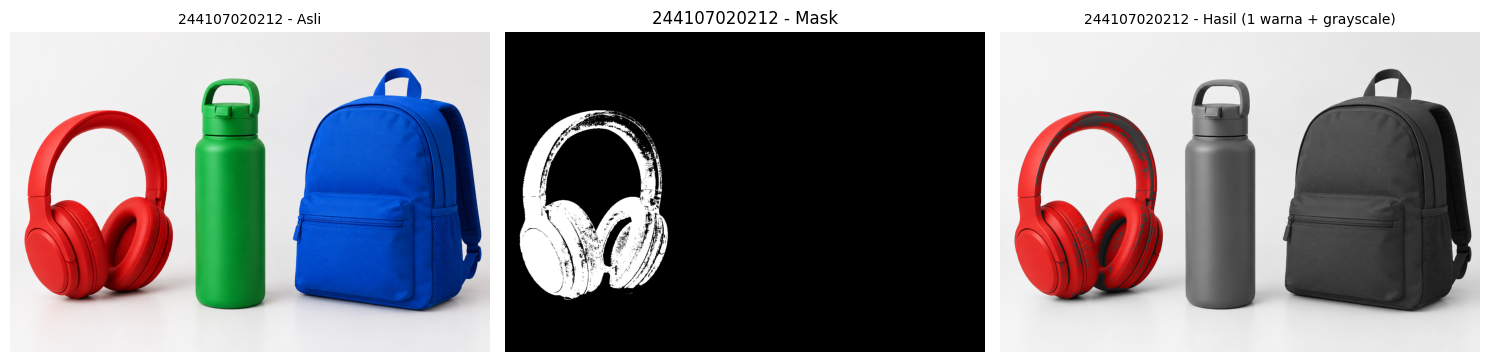

Rentang HSV dipakai -> lower: [  0 100 100]  upper: [ 10 255 255]


In [15]:
img_obj = cv.imread(BASE + '/OBJ1.jpg')
hsv = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

lower = np.array([0, 100, 100])     # contoh: rentang bawah untuk warna merah
upper = np.array([10, 255, 255])    # contoh: rentang atas untuk warna merah

mask = cv.inRange(hsv, lower, upper)

gray = cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

result = np.where(mask[:, :, None] == 255, img_obj, gray_3ch)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
cv2_imshow_rgb(axs[0], img_obj, NIM + ' - Asli')
axs[1].imshow(mask, cmap='gray'); axs[1].set_title(NIM + ' - Mask'); axs[1].axis('off')
cv2_imshow_rgb(axs[2], result, NIM + ' - Hasil (1 warna + grayscale)')
plt.tight_layout()
plt.show()

print('Rentang HSV dipakai -> lower:', lower, ' upper:', upper)
